In [1]:
import numpy as np
import pandas as pd
import plotly.express as px 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score , mean_squared_error

In [2]:
df = pd.read_csv('house_prices_practice.csv')

In [3]:
df.head(5)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [4]:
df['FullBath'].unique().sum()

np.int64(6)

In [5]:
df.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [6]:
df.drop(columns=['Id'] , axis=1 , inplace=True)

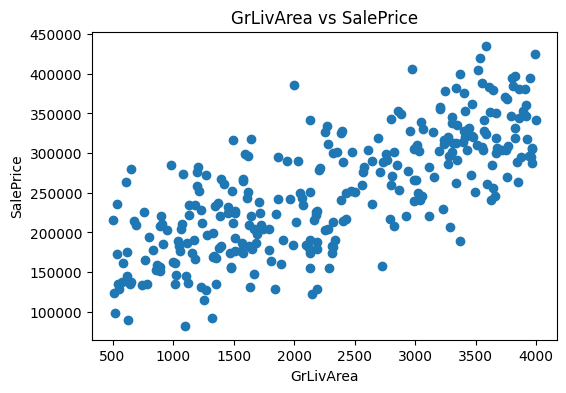

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()


Text(0, 0.5, 'SalePrice')

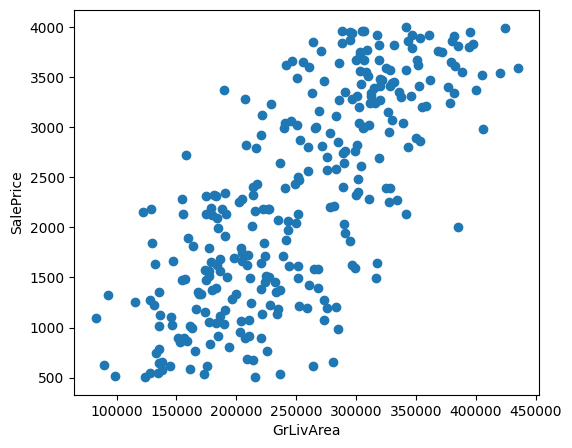

In [8]:
plt.figure(figsize=(6,5))
plt.scatter(df['SalePrice'],df['GrLivArea'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

In [9]:
x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [10]:
y

0      177106
1      301044
2      360609
3      240556
4      193656
        ...  
295    250604
296    329906
297    184623
298    303345
299    204982
Name: SalePrice, Length: 300, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size= 0.2,random_state=42 )

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [15]:
from sklearn.linear_model import Ridge , Lasso

In [16]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100]

line_model = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
line_model.fit(x_train_scaled, y_train)

y_pred = line_model.predict(x_test_scaled)


In [17]:
#line_model = LinearRegression() 
#line_model.fit(x_train,y_train)

In [18]:
y_pred = line_model.predict(x_test_scaled)
y_pred

array([239174.76469982, 190533.22617115, 397939.11376008, 223189.16057501,
       135244.00352872, 180288.70898148, 283690.08231784, 204555.93987639,
       205856.21120918, 171550.73497271, 389469.85848474, 274162.17724763,
       116288.29471191, 171385.86539991, 293863.32257082, 314786.74149602,
       155010.87456341, 146220.94194551, 221241.23724848, 255127.41233854,
       235776.36770882, 167474.79681655, 209002.81711122, 289799.09881971,
       313146.81290382, 382595.35779189, 206626.72331991, 260765.82515015,
       285217.0530016 , 443253.67753405, 402147.32724352, 292278.1043967 ,
       122275.00344478, 211057.86884972, 291042.04685408, 226597.22184195,
       342097.74241332, 243382.50778681, 235880.6956072 , 201552.72427629,
       237375.86917502, 334539.32009789, 313675.77141134, 292446.80432688,
       376898.38039466, 319355.17188493, 217332.4406466 , 256903.64835335,
       219011.15182501, 332402.53602871, 305636.28015033, 321551.97401138,
       110446.02024319, 3

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


RMSE: 12498.927032899688
R2 Score: 0.972465782798965


In [20]:
y_train_pred = line_model.predict(x_train_scaled)

from sklearn.metrics import r2_score
print("Train R2:", r2_score(y_train, y_train_pred))


Train R2: 0.9790354215472221


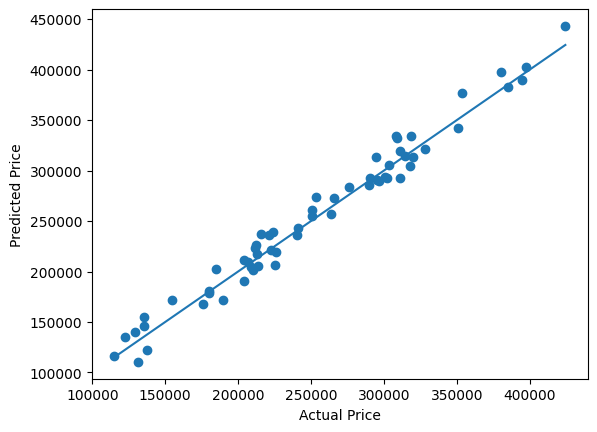

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()


In [22]:
import plotly.graph_objects as go

error = abs(y_test - y_pred)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    name='Predicted Prices',
    marker=dict(
        size=7,
        color=error,
        colorscale='Viridis',
        colorbar=dict(title='Absolute Error'),
        opacity=0.7
    )
))

fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction (y = x)',
    line=dict(
        width=3,
        dash='dash'
    )
))

fig.update_layout(
    title='Actual vs Predicted House Prices',
    xaxis_title='Actual Sale Price',
    yaxis_title='Predicted Sale Price',
    legend_title='Legend',
    template='plotly_white',
    width=800,
    height=650
)

fig.show()


In [23]:
import plotly.graph_objects as go

features = list(x.columns)
weights = line_model.coef_

fig = go.Figure()

fig.add_trace(go.Bar(
    x=weights,
    y=features,
    orientation='h',
    marker=dict(
        color=weights,
        colorscale='RdBu',
        colorbar=dict(title='Weight')
    ),
    name='Feature Weight'
))

fig.update_layout(
    title='Feature Importance (Linear Regression Weights)',
    xaxis_title='Weight',
    yaxis_title='Feature',
    template='plotly_white',
    width=900,
    height=500
)

fig.show()


In [24]:
x_test.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea
203,6,1456,2,2297,1958,3,2,2661
266,1,1796,1,2234,1998,2,1,10453
152,6,3856,3,1201,2022,1,4,8602
9,5,1492,1,2175,2011,1,2,11218
233,1,2149,0,394,1979,2,2,10555


In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(rmse)


12498.927032899688


In [26]:
import joblib

joblib.dump(line_model, r"E:\AMIT\DEPI_AIS2_G3_ml\src\ML\Session_2\linear_model.pkl")


['E:\\AMIT\\DEPI_AIS2_G3_ml\\src\\ML\\Session_2\\linear_model.pkl']